In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, recall_score, precision_score, roc_curve, auc, roc_auc_score

In [ ]:
data = pd.read_csv("/content/Telco_customer_churn.csv")
data.shape

(7043, 33)

In [ ]:
data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
data['Total Charges'] = pd.to_numeric(data['Total Charges'], errors='coerce')
original_rows = len(data)
data = data.dropna(subset=['Total Charges'])
print(f"Total dropped rows with NaNs: {original_rows - len(data)}")

Total dropped rows with NaNs: 11


In [ ]:
data.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
target_feature = 'Churn'
numeric_features = ['MonthlyCharges', 'TotalCharges', 'tenure']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
      'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

In [ ]:
target_feature = 'Churn Value'
numeric_features = ['Monthly Charges', 'Total Charges', 'Tenure Months']
categorical_features = ['Gender', 'Senior Citizen', 'Partner', 'Dependents',
      'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method']

In [ ]:
X = data[numeric_features + categorical_features]
y = data[target_feature]
from collections import Counter
Counter(y)

Counter({1: 1869, 0: 5163})

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, stratify=y)

In [ ]:
# y_train = y_train.map({'Yes': 1, 'No': 0})
# y_test = y_test.map({'Yes': 1, 'No': 0})
# y = y.map({'Yes': 1, 'No': 0})

In [ ]:
print(f"Original data churn rate: {y.mean():.2f}")
print(f"Training data churn rate: {y_train.mean():.2f}")
print(f"Testing data churn rate: {y_test.mean():.2f}")

Original data churn rate: 0.27
Training data churn rate: 0.27
Testing data churn rate: 0.27


In [ ]:
# feature selection
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Re-create X and y from the now-encoded 'data' DataFrame
# This ensures that all categorical columns in X are numerically encoded
X = data[numeric_features + categorical_features]
y = data[target_feature]

# FEATURE SELECTION
selector = SelectKBest(score_func=mutual_info_classif, k=10)

X_selected = selector.fit_transform(X, y)

# Get the names of the selected columns from the (now numerical) X
selected_columns = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_columns)

Selected Features:
Index(['Monthly Charges', 'Total Charges', 'Tenure Months', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Contract', 'Payment Method'],
      dtype='object')


In [ ]:
from sklearn.compose import ColumnTransformer
# Numeric Preprocessing Batch

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# Categorical Preprocessing Batch

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
# Combine both batches with ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)

    ],
    remainder = 'drop'
)

# Create the final, full-stack pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight = 'balanced',
        random_state = 42,

    ))
])

In [ ]:
clf_pipeline.fit(X_train, y_train)
y_predict = clf_pipeline.predict(X_test)
print(y_predict)

[1 1 1 ... 0 1 0]


In [ ]:
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]
print(y_proba)

[0.86173052 0.65627622 0.90641827 ... 0.01550195 0.60434395 0.22772928]


In [ ]:
print(recall_score(y_test, y_predict))

0.7878787878787878


In [ ]:
print(confusion_matrix(y_test, y_predict))

[[1119  430]
 [ 119  442]]


In [ ]:
print(precision_score(y_test, y_predict))

0.5068807339449541


In [ ]:
print(accuracy_score(y_test, y_predict))

0.7398104265402844


In [ ]:
print(f1_score(y_test, y_predict))

0.6168876482903001


In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1549
           1       0.51      0.79      0.62       561

    accuracy                           0.74      2110
   macro avg       0.71      0.76      0.71      2110
weighted avg       0.80      0.74      0.75      2110



In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print(roc_auc)

0.840256320851012


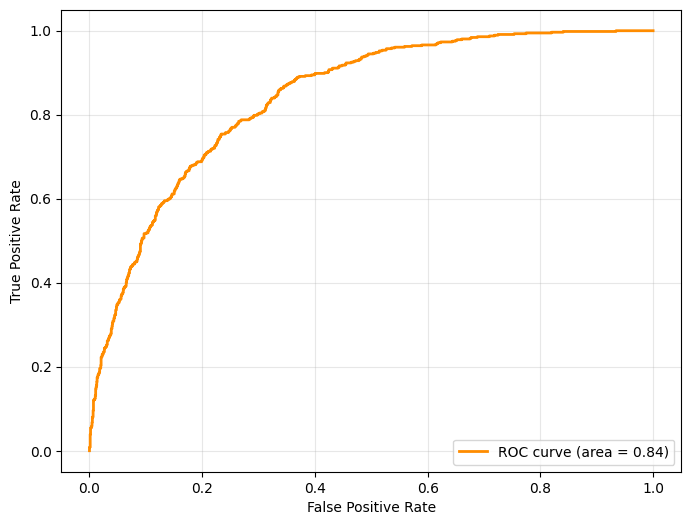

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators = 200,
        class_weight = 'balanced',
        random_state = 42,

    ))
])

In [ ]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Monthly Charges',
                                                   'Total Charges',
                                                   'Tenure Months']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1549
           1       0.62      0.51      0.56       561

    accuracy                           0.79      2110
   macro avg       0.72      0.70      0.71      2110
weighted avg       0.78      0.79      0.78      2110



In [ ]:
print(confusion_matrix(y_test, y_pred_rf))

[[1371  178]
 [ 275  286]]


In [ ]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)

0.8253246013470826


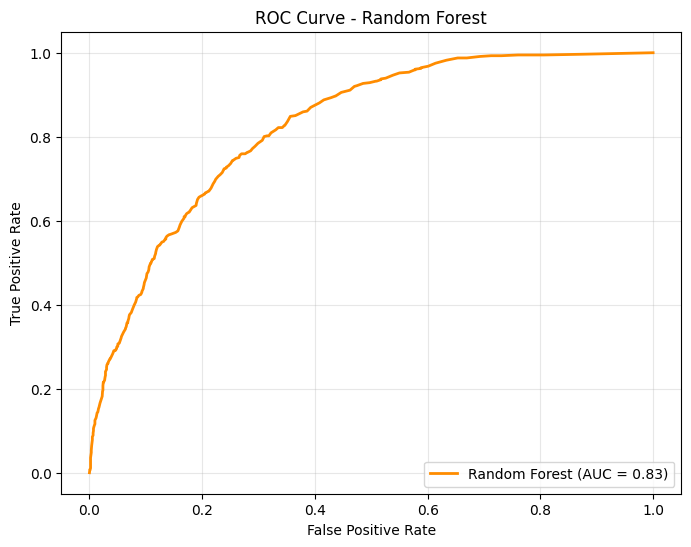

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(
    clf_pipeline, X_train, y_train,
    scoring='roc_auc',
    cv=5
)
print("Logistic Regression CV AUC:", cv_auc.mean())

Logistic Regression CV AUC: 0.862619185541341


In [ ]:
cv_auc = cross_val_score(
    rf_model, X_train, y_train,
    scoring='roc_auc',
    cv=5
)
print("Random Forest CV AUC:", cv_auc.mean())

Random Forest CV AUC: 0.8428606626531806


In [130]:
#Minimun Sample Split
#Minimum Sample leaf
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 10],
    'model__min_samples_leaf': [1, 5]
}

In [ ]:
grid_rf = GridSearchCV(
    rf_model,
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Monthly '
                                                                          'Charges',
                                                                          'Total '
                                                                          'Charges',
                                                                          'Tenure '
                                                                          'Months']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handl...
                                                                          'TV',
                                                                          'Streaming '
                                                                          'Movies',
                                                                          'Contract',
                                                                          'Paperless '
                                                                          'Billing',
                                                                          'Payment '
                                                                          'Method'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_estimators=200,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 5],
                         'model__min_samples_split': [2, 10],
                         'model__n_estimators': [200, 400]},
             scoring='roc_auc', verbose=2)

In [ ]:
print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV AUC:", grid_rf.best_score_)

Best RF Params: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 400}
Best RF CV AUC: 0.8673135991385151


In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

0.8436343843247728
0.7540284360189573
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1549
           1       0.53      0.74      0.61       561

    accuracy                           0.75      2110
   macro avg       0.71      0.75      0.72      2110
weighted avg       0.79      0.75      0.76      2110



In [ ]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(15)

,feature,importance
37,cat__Contract_Month-to-month,0.136635
2,num__Tenure Months,0.120239
1,num__Total Charges,0.090037
0,num__Monthly Charges,0.062772
39,cat__Contract_Two year,0.060152
19,cat__Online Security_No,0.056401
28,cat__Tech Support_No,0.047095
9,cat__Dependents_No,0.042653
17,cat__Internet Service_Fiber optic,0.042406
44,cat__Payment Method_Electronic check,0.042251


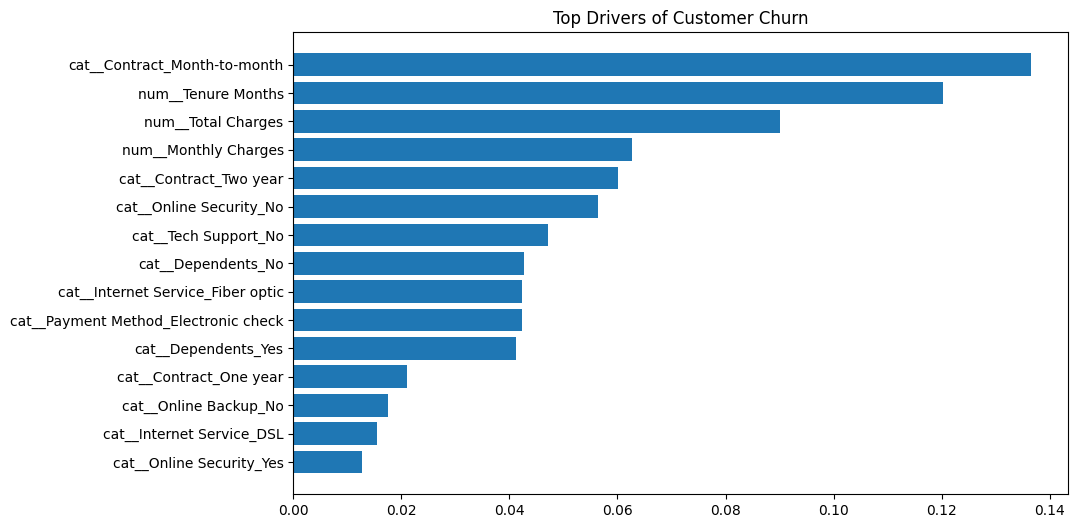

In [ ]:
top_features = feat_imp.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Drivers of Customer Churn")
plt.show()


In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_custom = (y_pred_proba_rf >= t).astype(int)

    precision = precision_score(y_test, y_pred_custom)
    recall = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)

    results.append((t, precision, recall, f1))

results_df = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])
results_df

,threshold,precision,recall,f1
0,0.10,0.354901,0.987522,0.522149
1,0.15,0.381119,0.971480,0.547464
2,0.20,0.407774,0.953654,0.571276
3,0.25,0.434783,0.926916,0.591918
4,0.30,0.456462,0.887701,0.602906
5,0.35,0.477432,0.848485,0.611040
6,0.40,0.498368,0.816399,0.618919
7,0.45,0.512338,0.777184,0.617564
8,0.50,0.526718,0.737968,0.614699
9,0.55,0.549374,0.704100,0.617188


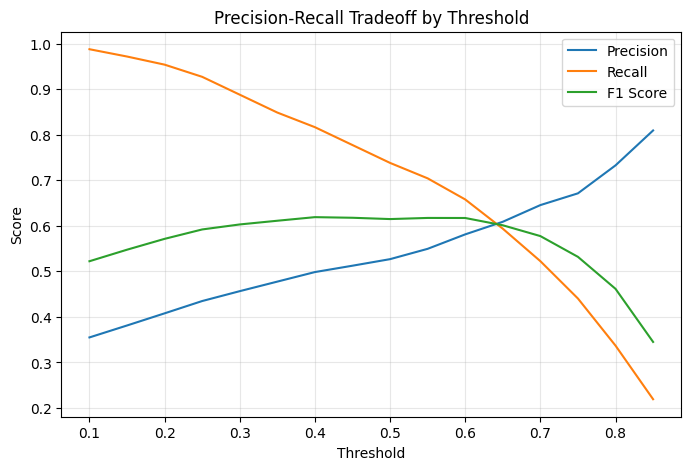

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision-Recall Tradeoff by Threshold")
plt.grid(alpha=0.3)
plt.show()


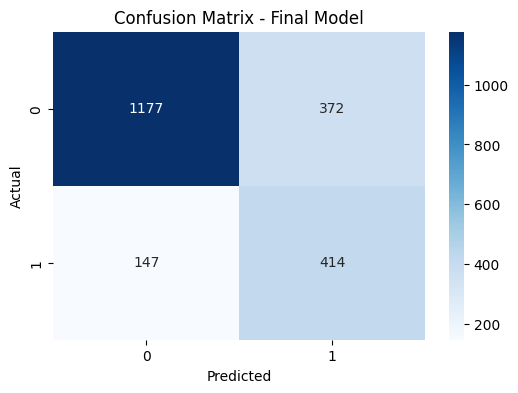

In [ ]:
y_pred_final = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model")
plt.show()

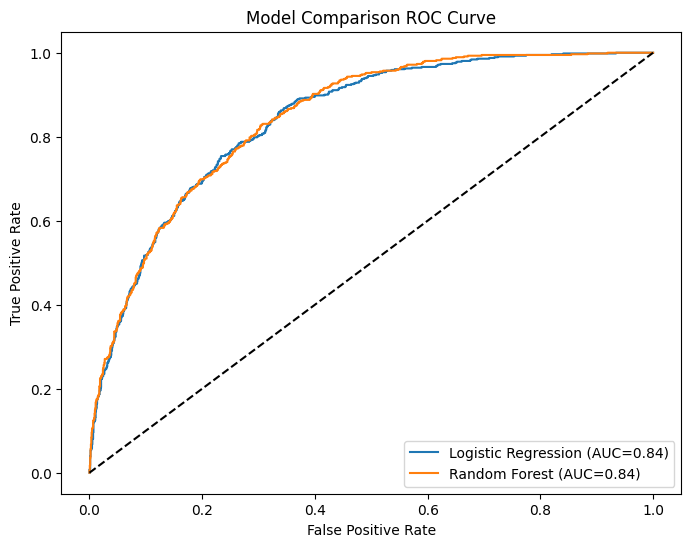

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={roc_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_rf:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model Comparison ROC Curve")
plt.legend()
plt.show()

In [ ]:
churn_prob = y_pred_proba_rf

risk_df = pd.DataFrame({
    "churn_probability": churn_prob
})

risk_df["risk_level"] = pd.cut(
    risk_df["churn_probability"],
    bins=[0,0.3,0.6,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

risk_df["risk_level"].value_counts()

,count
risk_level,
Low Risk,1019
High Risk,635
Medium Risk,456


In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
import shap

rf_classifier = best_rf.named_steps['model']

# Transform X_train using the preprocessor from the best_rf pipeline
X_train_transformed = best_rf.named_steps['preprocessor'].transform(X_train)

explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_train_transformed)
print(type(shap_values))
print(len(shap_values))
print(shap_values[1].shape)
print(X_train_transformed.shape)

<class 'numpy.ndarray'>
4922
(46, 2)
(4922, 46)


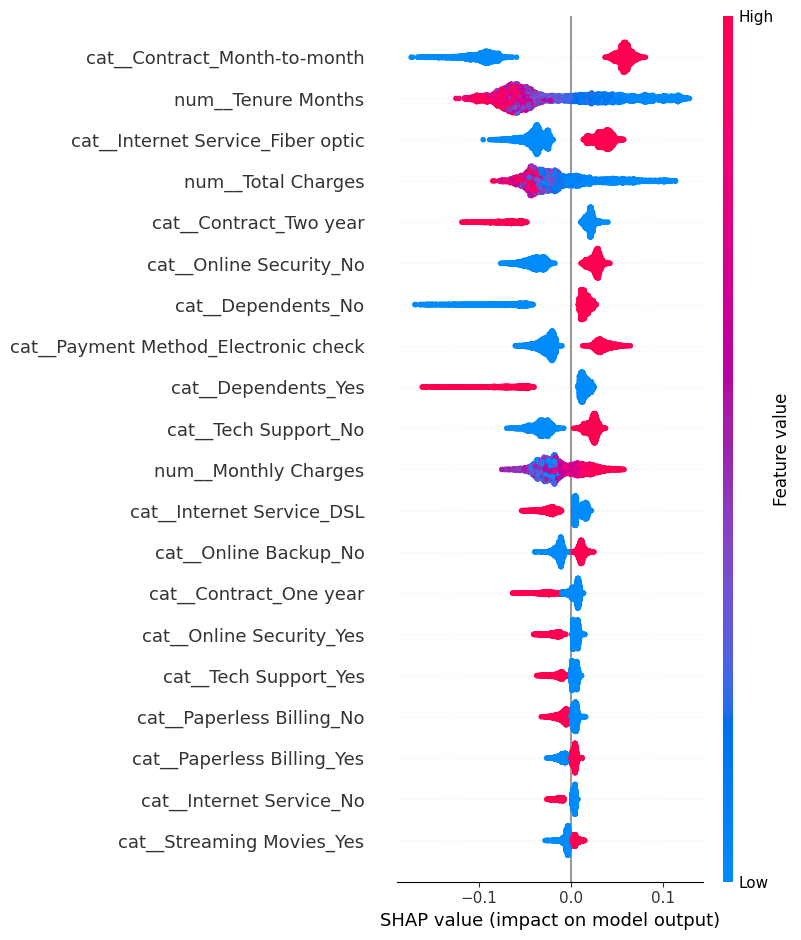

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed,
    feature_names=feature_names
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Recalculate scale_pos_weight based on the SMOTEd training data (y_train_smoted)
neg, pos = np.bincount(y_train_smoted)
scale_pos_weight = neg / pos

# Re-define the preprocessor for the pipelines (if it's not globally defined or overwritten)
# Re-using the structure from KRdQq3Hhpp6d to ensure consistency
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# Re-define and fit the XGBoost model pipeline
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    ))
])

# Fit the pipeline using the raw, SMOTEd training data (preprocessor will handle transformations)
xgb_model.fit(X_train_smoted, y_train_smoted)

# Crucial: Update the global X_test and y_test to the raw, consistent versions
# This ensures all subsequent metrics for LR, RF, and XGBoost use the same test set.
X_test = X_test_raw
y_test = y_test_raw

print("XGBoost model pipeline re-fitted with consistent data.")
print(f"Global X_test shape: {X_test.shape}")
print(f"Global y_test shape: {y_test.shape}")

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Monthly Charges',
                                                   'Total Charges',
                                                   'Tenure Months']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
from sklearn.preprocessing import LabelEncoder
# ENCODE CATEGORICAL VARIABLES
label = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = label.fit_transform(data[col])

In [ ]:
from imblearn.over_sampling import SMOTE
# CLASS IMBALANCE
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("Balanced Class Distribution")
print(pd.Series(y_train).value_counts())

Balanced Class Distribution
Churn Value
0    4130
1    4130
Name: count, dtype: int64


### Hyperparameter Tuning for XGBoost

In [126]:
param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1],
    'model__colsample_bytree': [0.8, 1]
}

# Use roc_auc for scoring as it's more appropriate for imbalanced classification
grid_xgb = GridSearchCV(
    estimator=xgb_model, # Use the pipeline as the estimator
    param_grid=param_grid_xgb,
    cv=3, # Reduced folds for quicker execution during testing
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

# Fit GridSearchCV using the SMOTEd training data (X_train_smoted, y_train_smoted)
# Note: The preprocessor within xgb_model will handle transformations.
grid_xgb.fit(X_train_smoted, y_train_smoted)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Monthly '
                                                                          'Charges',
                                                                          'Total '
                                                                          'Charges',
                                                                          'Tenure '
                                                                          'Months']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handl...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=200,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8, 1],
                         'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200, 300],
                         'model__subsample': [0.8, 1]},
             scoring='roc_auc', verbose=2)

In [127]:
print("Best XGBoost Parameters:")
print(grid_xgb.best_params_)
print("Best XGBoost CV AUC:", grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_

Best XGBoost Parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best XGBoost CV AUC: 0.9318062043913432


### Evaluate Tuned XGBoost Model

In [128]:
y_pred_xgb_tuned = best_xgb.predict(X_test_raw)
y_proba_xgb_tuned = best_xgb.predict_proba(X_test_raw)[:, 1]

print("Classification Report for Tuned XGBoost Model:")
print(classification_report(y_test_raw, y_pred_xgb_tuned))
print("ROC AUC (tuned XGBoost):", roc_auc_score(y_test_raw, y_proba_xgb_tuned))

Classification Report for Tuned XGBoost Model:
              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1549
           1       0.52      0.74      0.61       561

    accuracy                           0.75      2110
   macro avg       0.71      0.75      0.71      2110
weighted avg       0.79      0.75      0.76      2110

ROC AUC (tuned XGBoost): 0.8291129116709187


### Updated Model Performance Comparison

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1549
           1       0.51      0.76      0.61       561

    accuracy                           0.75      2110
   macro avg       0.71      0.75      0.71      2110
weighted avg       0.79      0.75      0.76      2110

ROC AUC: 0.8431061843130351


In [129]:
y_predict_lr = clf_pipeline.predict(X_test_raw)
y_proba_lr = clf_pipeline.predict_proba(X_test_raw)[:, 1]

# Random Forest (Tuned, from best_rf)
y_pred_rf_final = best_rf.predict(X_test_raw)
y_proba_rf_final = best_rf.predict_proba(X_test_raw)[:, 1]

# XGBoost (Initial, from xgb_model)
y_pred_xgb_initial = xgb_model.predict(X_test_raw)
y_proba_xgb_initial = xgb_model.predict_proba(X_test_raw)[:, 1]

# XGBoost (Tuned, from best_xgb)
# y_pred_xgb_tuned and y_proba_xgb_tuned are already calculated above

performance_df_final_updated = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest (Tuned)", "XGBoost (Initial)", "XGBoost (Tuned)"],
    "ROC AUC": [
        round(roc_auc_score(y_test_raw, y_proba_lr), 2),
        round(roc_auc_score(y_test_raw, y_proba_rf_final), 2),
        round(roc_auc_score(y_test_raw, y_proba_xgb_initial), 2),
        round(roc_auc_score(y_test_raw, y_proba_xgb_tuned), 2)
    ],
    "F1 Score": [
        round(f1_score(y_test_raw, y_predict_lr), 2),
        round(f1_score(y_test_raw, y_pred_rf_final), 2),
        round(f1_score(y_test_raw, y_pred_xgb_initial), 2),
        round(f1_score(y_test_raw, y_pred_xgb_tuned), 2)
    ],
    "Precision": [
        round(precision_score(y_test_raw, y_predict_lr), 2),
        round(precision_score(y_test_raw, y_pred_rf_final), 2),
        round(precision_score(y_test_raw, y_pred_xgb_initial), 2),
        round(precision_score(y_test_raw, y_pred_xgb_tuned), 2)
    ],
    "Recall": [
        round(recall_score(y_test_raw, y_predict_lr), 2),
        round(recall_score(y_test_raw, y_pred_rf_final), 2),
        round(recall_score(y_test_raw, y_pred_xgb_initial), 2),
        round(recall_score(y_test_raw, y_pred_xgb_tuned), 2)
    ]
})

display(performance_df_final_updated)

print("All model metrics successfully calculated and displayed with synchronized data.")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,ROC AUC,F1 Score,Precision,Recall
0,Logistic Regression,0.71,0.50,0.41,0.63
1,Random Forest (Tuned),0.75,0.00,0.00,0.00
2,XGBoost (Initial),0.76,0.00,0.00,0.00
3,XGBoost (Tuned),0.83,0.61,0.52,0.74


All model metrics successfully calculated and displayed with synchronized data.
